# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 12 </span>
## <span style="color:orange"> Keras - Deep & Convolutional Neural Network image recognition </span>

### MNIST with Keras

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises $70000$ handwritten digits, each of which comes in a square image, divided into a $28\times 28$ pixel grid. Every pixel can take on $256$ gradation of the gray color, interpolating between white and black, and hence each data point assumes any value in the set $\{0,1,\dots,255\}$. Since there are $10$ categories in the problem, corresponding to the ten digits, this problem represents a generic **classification task**. 

In [1]:
import os
import platform
import sys
from datetime import datetime
import random
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import tensorflow as tf
print("===== Checking Environment Specifications =====")
print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.initializers import GlorotUniform

random.seed(0)

np.random.seed(0)

tf.random.set_seed(0)

===== Checking Environment Specifications =====
Python: 3.11.13
Platform: macOS-15.6.1-arm64-arm-64bit
TensorFlow: 2.16.2
Keras: 3.11.3
NumPy: 1.26.4
Matplotlib: 3.10.7


## <span style="color:red"> <u>Note</u> </span>: ## 

It has been reported by users that Tensorflow version $\geq$ 2.19 with Python $\geq$ 3.12 causes Jupyter notebook's kernel to die especially when using ```model.fit()```. To solve this issue, I've created an Anaconda environment using previous versions of both Python and Tensorflow.

#### Step 1: Load and Process the Data

Keras can conveniently download the MNIST data from the web. All we need to do is import the `mnist` module and use the `load_data()` class, and it will create the training and test data sets or us.

The MNIST set has pre-defined test and training sets, in order to facilitate the comparison of the performance of different models on the data.

Once we have loaded the data, we need to format it in the correct shape.

In [2]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

print("X_train shape:", X_train.shape, "Memory (MB):", X_train.nbytes / 1e6)
print("Y_train shape:", Y_train.shape, "Memory (MB):", Y_train.nbytes / 1e6)
print("X_test shape:", X_test.shape, "Memory (MB):", X_test.nbytes / 1e6)
print("Y_test shape:", Y_test.shape, "Memory (MB):", Y_test.nbytes / 1e6)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)

60000 train samples
10000 test samples
X_train shape: (60000, 28, 28) Memory (MB): 47.04
Y_train shape: (60000,) Memory (MB): 0.06
X_test shape: (10000, 28, 28) Memory (MB): 7.84
Y_test shape: (10000,) Memory (MB): 0.01


an example of a data point with label 4


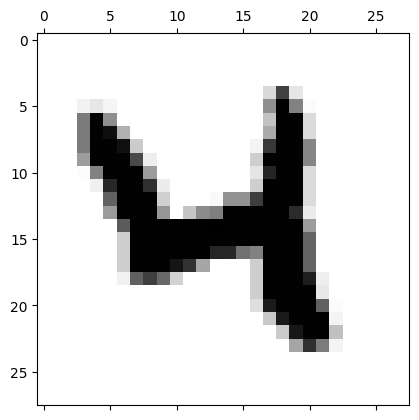

an example of a data point with label 4 before to_categorical ...
... and with label [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] after to_categorical

X_train shape: (60000, 784)
Y_train shape: (60000, 10)


In [3]:
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

# cast floats to single precesion
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
X_train /= 255
X_test /= 255

print('an example of a data point with label', Y_train[20])
# matshow: display a matrix in a new figure window
plt.matshow(X_train[20,:].reshape(28,28),cmap='binary')
plt.show()

print('an example of a data point with label', Y_train[20], 'before to_categorical ...')
# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
print('... and with label', Y_train[20], 'after to_categorical')
print()
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

#### Example: to_categorical

In [4]:
# Consider an array of 5 labels out of a set of 3 classes {0, 1, 2}:
labels = np.array([0, 2, 1, 2, 0])
# `to_categorical` converts this into a matrix with as many columns as there are classes.
# The number of rows stays the same.
keras.utils.to_categorical(labels)

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

#### Step 2: Define the Neural Net and its Architecture

We can now move on to construct our deep neural net. We shall use Keras's `Sequential()` class to instantiate a model, and will add different deep layers one by one using the `add()` method

For the purposes of our example, it suffices to focus on `Dense` layers for simplicity. Every `Dense()` layer accepts as its first required argument an integer which specifies the number of neurons. The type of activation function for the layer is defined using the `activation` optional argument, the input of which is the name of the activation function in `string` format. Examples include `relu`, `tanh`, `elu`, `sigmoid`, `softmax`. 

In order for our DNN to work properly, we have to make sure that the numbers of input and output neurons for each layer match. Therefore, we specify the shape of the input in the first layer of the model explicitly using the optional argument `input_shape=(N_features,)`. The sequential construction of the model then allows Keras to infer the correct input/output dimensions of all hidden layers automatically. Hence, we only need to specify the size of the softmax output layer to match the number of categories.

In [5]:
# Clear previous models from memory
K.clear_session()

def create_DNN():
    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))  # First layer defines input
    # add a dense all-to-all relu layer
    model.add(Dense(400, activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5 (i.e. 50% of random neurons are set to zero during training)
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


### <u>Note</u>: Dropout

Dropout is a ```layer``` class in ```tensorflow.keras.layers```. It is a regularization technique (i.e. it renders the model "well-behaved) that prevents overfitting by randomly selecting $x$% of the neurons and setting them to 0. This makes the model less reliant on specific neurons, eventually helping it to generalize well. 

#### Step 3: Choose the Optimizer and the Cost Function

Next, we choose the loss function according to which to train the DNN. For classification problems, this is the cross entropy, and since the output data was cast in categorical form, we choose the `categorical_crossentropy` defined in Keras' `losses` module. Depending on the problem of interest one can pick any other suitable loss function. To optimize the weights of the net, we choose SGD. This algorithm is already available to use under Keras' `optimizers` module, but we could use any other built-in one as well. The parameters for the optimizer, such as `lr` (learning rate) or `momentum` are passed using the corresponding optional arguments of the `SGD()` function. All available arguments can be found in Keras' online documentation at [https://keras.io/](https://keras.io/). While the loss function and the optimizer are essential for the training procedure, to test the performance of the model one may want to look at a particular `metric` of performance. For instance, in categorical tasks one typically looks at their `accuracy`, which is defined as the percentage of correctly classified data points. To complete the definition of our model, we use the `compile()` method, with optional arguments for the `optimizer`, `loss`, and the validation `metric` as follows:

In [6]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adamax, Nadam

def compile_model():
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=SGD(),
                  metrics=['acc'])
    return model

print('Model compiled successfully and ready to be trained.')

Model compiled successfully and ready to be trained.


#### Step 4: Train the model

We train our DNN in minibatches. 

Shuffling the training data during training improves stability of the model. Thus, we train over a number of training epochs. Each epoch corresponds to using **all the train data** divided in minibatches.

Training the DNN is a one-liner using the `fit()` method of the `Sequential` class. The first two required arguments are the training input and output data. As optional arguments, we specify the mini-`batch_size`, the number of training `epochs`, and the test or `validation_data`. To monitor the training procedure for every epoch, we set `verbose=True`. 

## Important note on testing vs. training validation ##
---------

Our mnist dataset (70k elements) is split the following way:

- **Training Dataset** (60k elements), among which: <br><br>
  - $\approx$ 48k elements are effectively used for training. Results are stored in ```history['acc']``` and ```history['loss']```
  - $\approx$ 12k elements are used for training validation. Results are stored in ```history['val_acc']``` and ```history['val_loss']```<br><br>
- **Testing Dataset** (10k elements):
  This is the **unseen** data with which the model tests its final performance after training. When evaluating a model, the results are stored respectively in ```score[0]``` (test loss) and ```score[1]``` (test accuracy). Each of the two results are the **mean performance** across all elements of the testing dataset.

In [7]:
# training parameters
batch_size = 32
epochs = 5

# create the deep neural net
model_DNN = compile_model()

# train DNN and store training info in history
history = model_DNN.fit(x=X_train, y=Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          validation_data=(X_test, Y_test),
          verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7775 - loss: 0.7618 - val_acc: 0.9138 - val_loss: 0.3119
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8899 - loss: 0.3865 - val_acc: 0.9315 - val_loss: 0.2380
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9114 - loss: 0.3103 - val_acc: 0.9427 - val_loss: 0.1983
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9242 - loss: 0.2669 - val_acc: 0.9498 - val_loss: 0.1724
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9334 - loss: 0.2365 - val_acc: 0.9547 - val_loss: 0.1560


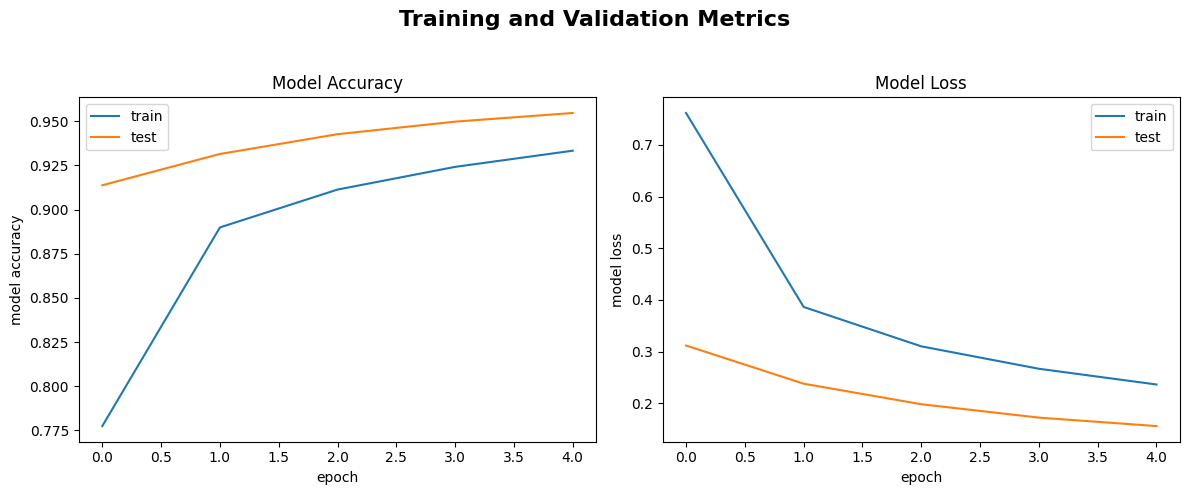

In [8]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(history.history['acc'])
axes[0].plot(history.history['val_acc'])
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('model accuracy')
axes[0].set_xlabel('epoch')
axes[0].legend(['train', 'test'], loc='best')

axes[1].plot(history.history['loss'])
axes[1].plot(history.history['val_loss'])
axes[1].set_title('Model Loss')
axes[1].set_ylabel('model loss')
axes[1].set_xlabel('epoch')
axes[1].legend(['train', 'test'], loc='best')

fig.suptitle('Training and Validation Metrics', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Step 5: Evaluate the Model Performance on the *Unseen* Test Data

Next, we evaluate the model and read of the loss on the test data, and its accuracy using the `evaluate()` method.

In [9]:
# Evaluate model on the test set
score = model_DNN.evaluate(X_test, Y_test, verbose=1)
test_loss = score[0]
test_accuracy = score[1]

print(r"Mean loss value on unseen data: ", test_loss)
print(r"Mean accuracy value on unseen data: ", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - acc: 0.9547 - loss: 0.1560
Mean loss value on unseen data:  0.15603847801685333
Mean accuracy value on unseen data:  0.9546999931335449


Dropout, during training, slices off some artificial neurons, thus, training accuracy suffers.

Dropout, during testing, turns itself off and allows all of the ‘weak classifiers’ in the neural network to be used. Thus, testing accuracy improves with respect to training accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step


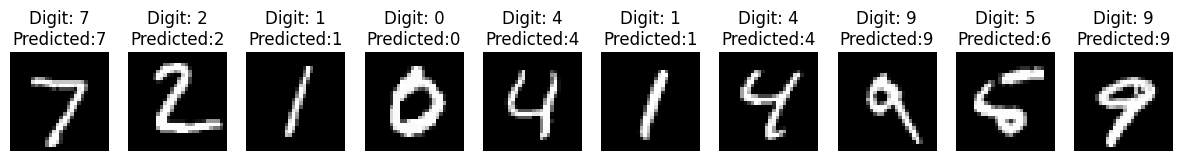

In [10]:
#X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:{}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

### Exercise 12.1

By keeping fixed all the other parameters, try to use at least two other optimizers, different from SGD. <span style="color:red">Watch to accuracy and loss for training and validation data and comment on the performances</span>.

## Testing Different Optimizers ##
---------------

### RMSProp (Root Mean Square Propagation) ###
  
  RMSProp works essentially the same way as SGD with the notable difference that it uses an adaptive learning rate instead of a fixed one.
  
### Adam (Adaptive Moment Estimation) ###

In that context the term "momentum" is inspired by its physical counterpart. That is, momentum can "build up" during the training process. Specifically, while in plain SGD each parameters update depends on the current gradient, with Adam each update also takes into account the value of the previous gradient. This has several benefits, among which:

- If the slope in parameters space is shallow building up momentum and training is faster
- The model escapes gradient local minima thanks to its momentum

In [11]:
# Redefining compile_model()
def compile_model(optimizer):
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])
    return model

In [12]:
# training parameters
batch_size = 32
epochs = 5

# create two different deep neural nets. One implemented with Adam, the other with RMSProp

model_DNN_adam = compile_model(Adam())
model_DNN_RMSProp = compile_model(RMSprop())

print("=== Before reshape ===")
print(r"X_train.shape: ", X_train.shape)
print(r"X_test.shape: ", X_test.shape)

X_train = X_train.reshape(X_train.shape[0], -1)  # (60000, 784)
X_test  = X_test.reshape(X_test.shape[0], -1)    # (10000, 784)

print("== After reshape ===")
print(r"X_train.shape: ", X_train.shape)
print(r"X_test.shape: ", X_test.shape)


# train DNN and store training info in history
print("=== Training Model with Adam Optimizer ===")
history_adam = model_DNN_adam.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          validation_data=(X_test, Y_test),
          verbose=1)

print("=== Training Model with RMSProp Optimizer ===")
history_RMSProp = model_DNN_RMSProp.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          validation_data=(X_test, Y_test),
          verbose=1)

=== Before reshape ===
X_train.shape:  (60000, 784)
X_test.shape:  (10000, 28, 28, 1)
== After reshape ===
X_train.shape:  (60000, 784)
X_test.shape:  (10000, 784)
=== Training Model with Adam Optimizer ===
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9193 - loss: 0.2769 - val_acc: 0.9631 - val_loss: 0.1123
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9658 - loss: 0.1201 - val_acc: 0.9696 - val_loss: 0.0989
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9747 - loss: 0.0861 - val_acc: 0.9731 - val_loss: 0.0899
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9797 - loss: 0.0686 - val_acc: 0.9701 - val_loss: 0.1023
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9834 - loss: 0.0553 - val_acc: 0.9801 - val_loss: 0.0768
=== Training Model with RMSProp Optimizer ===
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9209 - loss: 0.2745 - val_acc: 0.9664 - val_loss: 0.1271
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - acc: 0.9547 - loss: 0.1560
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - acc: 0.9756 - loss: 0.1536
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - acc: 0.9801 - loss: 0.0768


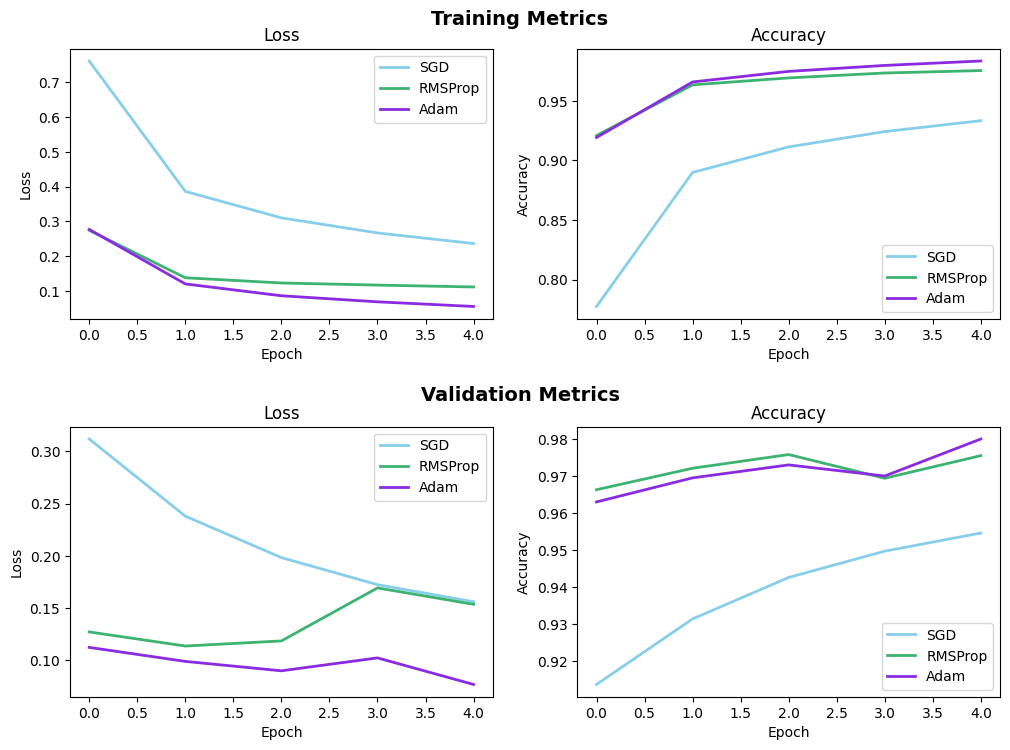

In [13]:
# Comparing the models accuracy and loss using different optimizers

# ----- Training -----
y_SGD = history
y_RMSProp = history_RMSProp
y_adam = history_adam

# ----- Testing ------
score = model_DNN.evaluate(X_test, Y_test, verbose=1)
score_RMSProp = model_DNN_RMSProp.evaluate(X_test, Y_test, verbose=1)
score_adam = model_DNN_adam.evaluate(X_test, Y_test, verbose=1)


fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)

colors = ['skyblue', 'mediumseagreen', 'blueviolet']


# Training Loss
for c, hist in zip(colors, [y_SGD, y_RMSProp, y_adam]):
    axes[0, 0].plot(hist.history['loss'], color=c, linewidth=2)
axes[0, 0].set_title('Loss')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend(['SGD', 'RMSProp', 'Adam'])


# Training Accuracy
for c, hist in zip(colors, [y_SGD, y_RMSProp, y_adam]):
    axes[0, 1].plot(hist.history['acc'], color=c, linewidth=2)
axes[0, 1].set_title('Accuracy')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend(['SGD', 'RMSProp', 'Adam'])


# Validation Loss
for c, hist in zip(colors, [y_SGD, y_RMSProp, y_adam]):
    axes[1, 0].plot(hist.history['val_loss'], color=c, linewidth=2)
axes[1, 0].set_title('Loss')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend(['SGD', 'RMSProp', 'Adam'])


# Validation Accuracy
for c, hist in zip(colors, [y_SGD, y_RMSProp, y_adam]):
    axes[1, 1].plot(hist.history['val_acc'], color=c, linewidth=2)
axes[1, 1].set_title('Accuracy')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend(['SGD', 'RMSProp', 'Adam'])


fig.text(0.5, 0.95, 'Training Metrics', ha='center', fontsize=14, fontweight='bold')
fig.text(0.5, 0.48, 'Validation Metrics', ha='center', fontsize=14, fontweight='bold')

fig.subplots_adjust(top=0.92, hspace=0.4)
plt.show()

#### Creating Convolutional Neural Nets with Keras

We have so far considered each MNIST data sample as a $(28\times 28,)$-long 1d vector. On the other hand, we do know that in every one of the hand-written digits there are *local* spatial correlations between the pixels, but also *translational invariance*, which we would like to take advantage of to improve the accuracy of our classification model. To this end, we first need to reshape the training and test input data as follows

In [14]:
from keras.layers import Flatten, Conv2D, MaxPooling2D

# reshape data
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


One can ask the question of whether a neural net can learn to recognize such local patterns. This can be achieved by using convolutional layers.

### Exercise 12.2

Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end. I have merged step 2 and 3 in the following definition of `create_CNN()` that **<span style="color:red">you should complete</span>**:

## Convolutional NN using Keras ##
-------------

The logic behind CNN in keras is the following:
- ```Conv2D``` extracts features using filters:
    - This is a 2D convolutional layer, used for processing images (2D data).
    - It slides filters (kernels) over the input image to detect features like edges, textures, or patterns.
- The number ```10```is the number of filters (or feature maps) in this layer.
    - Each filter will produce a separate 2D output, so after this layer, the output shape will have 10 channels.
    - Essentially, the network learns 10 different feature detectors at this layer.
- ```kernel_size=(5, 5)```
    - This defines the receptive field, i.e., the local patch of the image each filter “looks at” at a time.
    - The filter slides across the image and computes a dot product between the filter weights and the image patch.
- ```activation='relu'``` usual activation function
- ```input_shape=input_shape``` Specifies the shape of the input images (height, width, channels).
    - Example: (28, 28, 1) for grayscale MNIST images

---------

After convolutional layers, the data is still 2D feature maps (height × width × channels).
Before feeding it to a fully connected layer (Dense), you need to flatten it into a 1D vector:

--------

- ```MaxPooling2D``` reduces spatial size and keeps strongest features.
- ```Flatten``` converts 2D feature maps to 1D vector.
- ```Dense``` layers perform classification.
- ```Dropout``` helps prevent overfitting.

In [15]:
def create_CNN():
    # instantiate model
    model = Sequential()
    # Explicitly define the input layer
    model.add(Input(shape=input_shape))
    # add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu'))
    # "Flattens" the output (converts (24,24,10) into (5760,))
    model.add(Flatten())               

    # Adding output layer, "flattening" the previous layer
    model.add(Dense(10, activation='softmax'))
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='SGD',
                  metrics=['accuracy'])
    return model

Train your DCNN and evaluate its performance proceeding exactly as before:

In [16]:
# create the deep conv net
model_CNN=create_CNN()

# getting a summary about the CNN structure
model_CNN.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        57,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,870 (226.05 KB)

 Trainable params: 57,870 (226.05 KB)

 Non-trainable params: 0 (0.00 B)

### A few comments on the shapes of the layers ###
----------

Layer ```conv2d``` output shape: ```(None, 24,24, 10)```:
- This is the layer after the first convolution. After the input is fed through a first series of "filters", it produces a **feature map**, with reduced dimension with respect to the input. Specifically, this feature map has size ```(None, 24,24, 10)``` meaning ```(batch size, width,height, number of filters)```

In [17]:
# training parameters
batch_size = 32
epochs = 5

# train CNN
history_CNN = model_CNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(X_test, Y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8769 - loss: 0.4381 - val_accuracy: 0.9094 - val_loss: 0.3084
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9188 - loss: 0.2842 - val_accuracy: 0.9334 - val_loss: 0.2363
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9419 - loss: 0.2106 - val_accuracy: 0.9545 - val_loss: 0.1697
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9577 - loss: 0.1563 - val_accuracy: 0.9651 - val_loss: 0.1300
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9662 - loss: 0.1248 - val_accuracy: 0.9695 - val_loss: 0.1078


In [18]:
# evaluate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - accuracy: 0.9695 - loss: 0.1078

Test loss: 0.10776439309120178
Test accuracy: 0.9695000052452087


In the end, **<span style="color:red">add the evaluation of your CNN performances</span>** like that used for the DNN.

## Comparing CNN vs. DNN performances ##
--------------

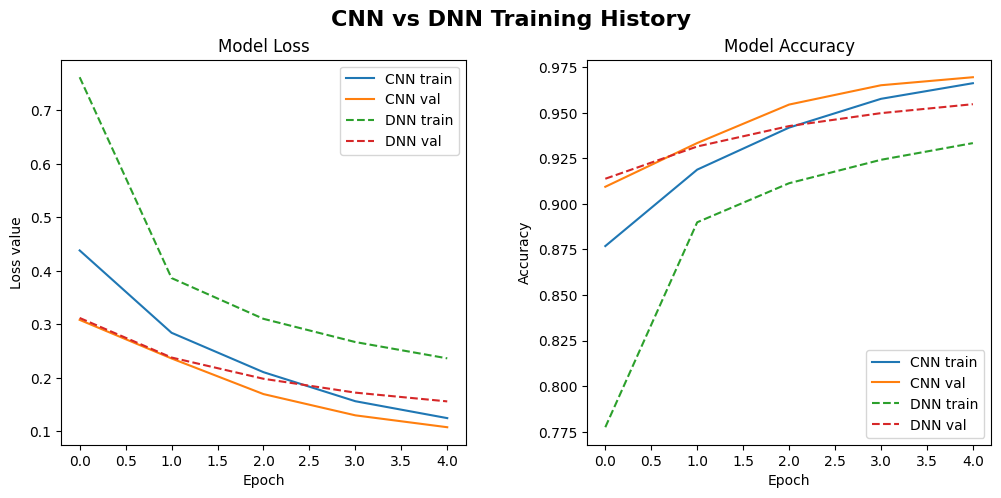

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- LOSS ---
axes[0].plot(history_CNN.history['loss'], label='CNN train', linestyle='-')
axes[0].plot(history_CNN.history['val_loss'], label='CNN val', linestyle='-')
axes[0].plot(history.history['loss'], label='DNN train', linestyle='--')
axes[0].plot(history.history['val_loss'], label='DNN val', linestyle='--')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss value')
axes[0].legend(loc='best')

# --- ACCURACY ---
axes[1].plot(history_CNN.history['accuracy'], label='CNN train', linestyle='-')
axes[1].plot(history_CNN.history['val_accuracy'], label='CNN val', linestyle='-')
axes[1].plot(history.history['acc'], label='DNN train', linestyle='--')
axes[1].plot(history.history['val_acc'], label='DNN val', linestyle='--')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

fig.suptitle('CNN vs DNN Training History', fontsize=16, fontweight='bold')
fig.subplots_adjust(top=0.88, wspace=0.3)
plt.show()

### Exercise 12.3

Use the `gimp` application to create 10 pictures of your "handwritten" digits, import them in your jupyter-notebook and try to see if your CNN is able to recognize your handwritten digits.

For example, you can use the following code to import a picture of an handwritten digit
(Note: you should install Python Image Library (PIL/Pillow):

Image size: 28x28


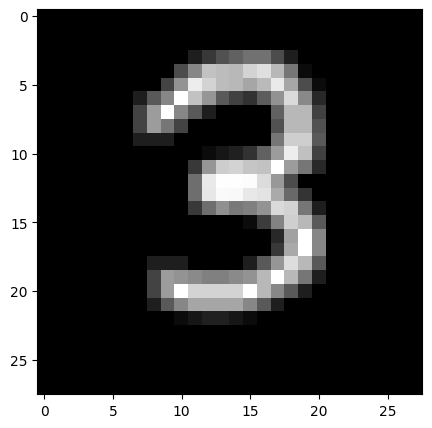

(28, 28)


In [22]:
from PIL import Image
import os

digit_filename = "./own_digits/own_3.png"
digit_in = Image.open(digit_filename).convert('L')

ydim, xdim = digit_in.size
print("Image size: "+str(xdim)+"x"+str(ydim))
pix=digit_in.load();
data = np.zeros((xdim, ydim))
for j in range(ydim):
    for i in range(xdim):
        data[i,j]=pix[j,i]

data /= 255

plt.figure(figsize=(5,5))
plt.imshow(data, cmap='gray')
plt.show()

print(data.shape)

I use the previously trained DNN to predict the digit:

(28, 28)
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


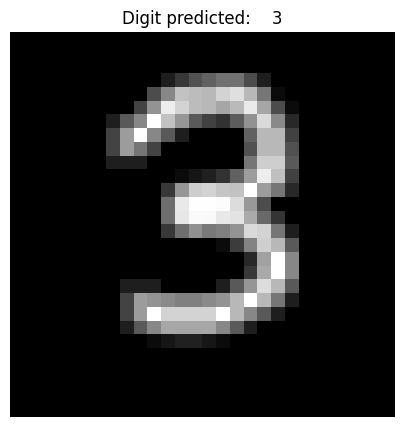

In [23]:
print(data.shape)
data = data.reshape(1,xdim*ydim)
print(data.shape)
pred_0 = model_DNN.predict(data)

data = data.reshape(xdim,ydim)

plt.figure(figsize=(5, 5))  
plt.imshow(data, cmap='gray')    
plt.title("Digit predicted:    {}".format(np.argmax(pred_0)))
plt.axis('off') 
plt.show()

### <span style="color:green">Supplementary information 1: Use of `gimp` </span>

- from the Unix shell type: `gimp` and hit `Return`
- File -> new (chose: 28x28 pixels)
- rascale the image to 800%
- Use the **brush** with dimension 2px to draw your digit
- Color -> invert (to have black background)
- Export the image as a `.png` file

That's all!

### <span style="color:green">Supplementary information 2: Display trained filters in your CNN</span>

Print your NN layers:

Display your filters:

### <span style="color:green">Supplementary information 3: Monitor layer outputs in your CNN</span>